In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Set global visualization style
sns.set_theme(style="whitegrid")

print("--- RQ3: Loading Dataset ---")
df = pd.read_csv('youtube_comments_with_sentiment.csv')
df = df.dropna(subset=['clean_comment'])

# Define features (X) and target (y)
X = df['clean_comment']
y = df['sentiment']

print(f"Dataset loaded successfully. Total comments to classify: {len(df)}")

--- RQ3: Loading Dataset ---
Dataset loaded successfully. Total comments to classify: 1572


In [5]:
print("--- RQ3: Executing Feature Extraction & Model Training ---")

# 1. Stratified split to maintain class balance (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 2. TF-IDF Vectorization (Extracting Text to Numbers)
vectorizer = TfidfVectorizer(max_features=1000, stop_words='english')
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# 3. Logistic Regression Model Initialization and Training
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_tfidf, y_train)

print("Logistic Regression Model training complete.")

--- RQ3: Executing Feature Extraction & Model Training ---
Logistic Regression Model training complete.


--- RQ3: Evaluation & Graph 3.1 ---
Overall Model Accuracy: 63.81%



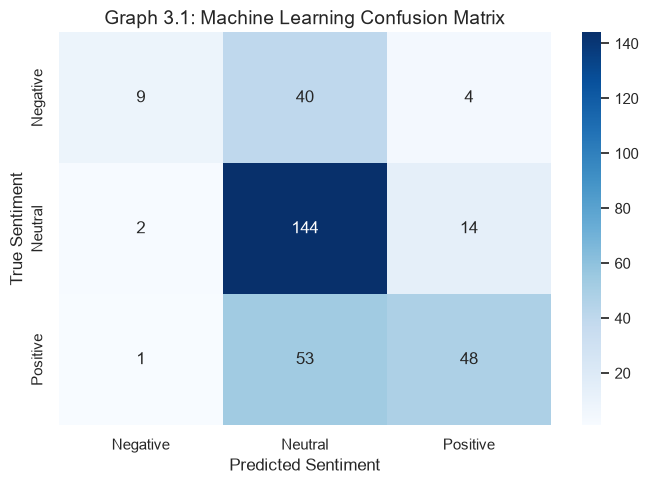

In [6]:
print("--- RQ3: Evaluation & Graph 3.1 ---")

# Make predictions
y_pred = lr_model.predict(X_test_tfidf)

# Calculate and print Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Overall Model Accuracy: {accuracy * 100:.2f}%\n")

# Graph 3.1: Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred, labels=['Negative', 'Neutral', 'Positive'])

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Negative', 'Neutral', 'Positive'], 
            yticklabels=['Negative', 'Neutral', 'Positive'])
plt.title('Graph 3.1: Machine Learning Confusion Matrix', fontsize=14)
plt.xlabel('Predicted Sentiment')
plt.ylabel('True Sentiment')
plt.tight_layout()
plt.savefig('rq3_graph1_confusion_matrix.png')
plt.show()

--- RQ3: Generating Graph 3.2 ---


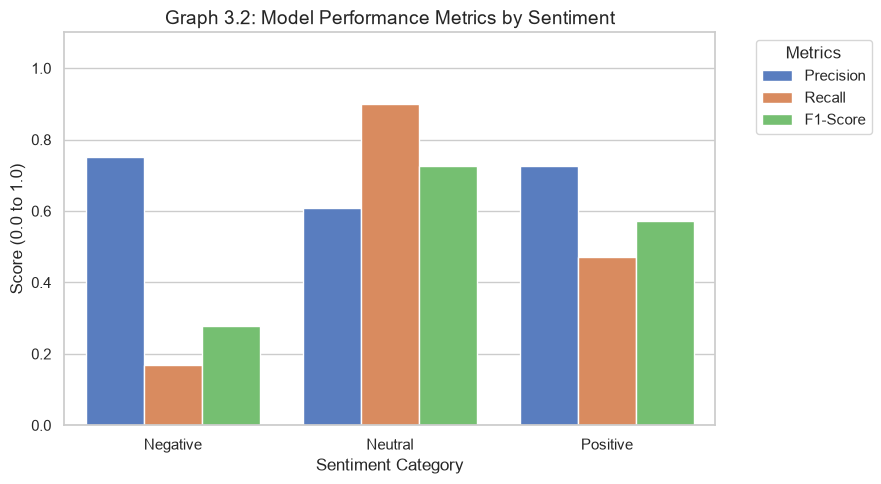

In [7]:
print("--- RQ3: Generating Graph 3.2 ---")

# Extracting metrics for the bar chart
report = classification_report(y_test, y_pred, output_dict=True)
categories = ['Negative', 'Neutral', 'Positive']

metrics_df = pd.DataFrame({
    'Category': categories,
    'Precision': [report[cat]['precision'] for cat in categories],
    'Recall': [report[cat]['recall'] for cat in categories],
    'F1-Score': [report[cat]['f1-score'] for cat in categories]
})

# Melt DataFrame for easier plotting with Seaborn
metrics_melted = metrics_df.melt(id_vars='Category', var_name='Metric', value_name='Score')

# Graph 3.2: Grouped Bar Chart
plt.figure(figsize=(9, 5))
sns.barplot(data=metrics_melted, x='Category', y='Score', hue='Metric', palette='muted')
plt.title('Graph 3.2: Model Performance Metrics by Sentiment', fontsize=14)
plt.ylabel('Score (0.0 to 1.0)')
plt.xlabel('Sentiment Category')
plt.ylim(0, 1.1)
plt.legend(title='Metrics', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('rq3_graph2_metrics_bar.png')
plt.show()

--- RQ3: Generating Graph 3.3 ---


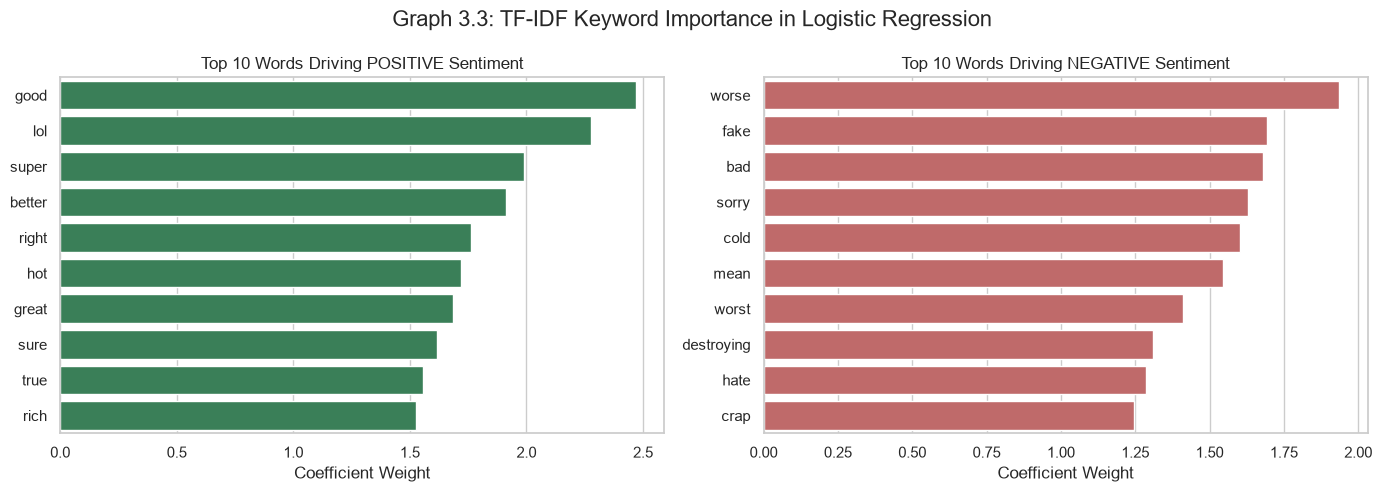

In [8]:
print("--- RQ3: Generating Graph 3.3 ---")

# Get feature names (words) and model coefficients
feature_names = np.array(vectorizer.get_feature_names_out())

# Extract coefficients for Negative (Class 0) and Positive (Class 2)
negative_coefs = lr_model.coef_[0] 
positive_coefs = lr_model.coef_[2]

# Identify the Top 10 words
top_negative_indices = negative_coefs.argsort()[-10:][::-1]
top_positive_indices = positive_coefs.argsort()[-10:][::-1]

top_neg_words = feature_names[top_negative_indices]
top_neg_weights = negative_coefs[top_negative_indices]

top_pos_words = feature_names[top_positive_indices]
top_pos_weights = positive_coefs[top_positive_indices]

# Graph 3.3: Dual Horizontal Bar Chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(x=top_pos_weights, y=top_pos_words, ax=axes[0], color='seagreen')
axes[0].set_title('Top 10 Words Driving POSITIVE Sentiment')
axes[0].set_xlabel('Coefficient Weight')

sns.barplot(x=top_neg_weights, y=top_neg_words, ax=axes[1], color='indianred')
axes[1].set_title('Top 10 Words Driving NEGATIVE Sentiment')
axes[1].set_xlabel('Coefficient Weight')

plt.suptitle('Graph 3.3: TF-IDF Keyword Importance in Logistic Regression', fontsize=16)
plt.tight_layout()
plt.savefig('rq3_graph3_feature_weights.png')
plt.show()

In [9]:
print("--- RQ3: Exporting Final Predictions ---")

# Create a DataFrame with the test results
output_df = pd.DataFrame({
    'Clean_Comment': X_test, 
    'True_Sentiment': y_test, 
    'Predicted_Sentiment': y_pred
})

output_df.to_csv('rq3_final_ml_predictions.csv', index=False)
print("Processing complete. Saved 'rq3_final_ml_predictions.csv'.")

--- RQ3: Exporting Final Predictions ---
Processing complete. Saved 'rq3_final_ml_predictions.csv'.
